# CNNs and ResNets

## PyTorch `nn.Module`

First we will start with the basics of creating different models.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
import einops

from torch import Tensor
from jaxtyping import Float, Int
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

### The `nn.Parameter` class

`nn.Parameter` is a special type of `Tensor` object. It's, at its core, the class that PyTorch has provided for storing the weights and biases of a `Module`.

* If a `Parameter` is set as an attribute of a `Module`, it will be detected by PyTorch automatically and returned when calling `module.parameters()`.
* This makes it easy to pass all parameters of a model into an optimizer and update them at all once. 

We can also printing information with `extra_repr`:

`extra_repr` allows us to format the string representation of our `Module` in a more informative way than the default.


```python
class MyModule(nn.Module):
    def __init__(self, arg1, arg2, ...):
        super().__init__()

    def extra_repr(self) -> str:
        return f"arg1={self.arg1}, arg2={self.arg2}, ..."
```

### Implementing ReLU

ReLU takes in a `Tensor` object and returns the elements of the `Tensor` if it is greater than 0, otherwise, it replaces those elements with 0.


$$ReLU = \max \{0, t\}$$

In [27]:
class ReLU(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        return torch.maximum(torch.tensor(0.0), x)

relu = ReLU()
x = torch.randn(5)
print(f"{x=}")
print(f"{relu(x)=}")


x=tensor([ 0.0962, -0.9594,  1.9421, -2.3834,  0.1749])
relu(x)=tensor([0.0962, 0.0000, 1.9421, 0.0000, 0.1749])


### Implementing Linear Module

Based on the PyTorch documentation found [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html).

Based on this documentation the `Linear` module applies an affine linear transformation:

$$
y = XW^{T} + b
$$

__Parameters__:
* __in_features__ (_int_) - size of each input sample
* __out_features__ (_int_) - size of each input sample
* __bias__ (_bool_) - if set to `False`, layer will not learn an additive bias

__Shape__:
* Input `(*, H_in)` where `*` means any number of dimension including `None`.
* Output `(*, H_in)` where all but the last dimension are the same shape as the input and $H_{out}=\textbf{out\_features}$ 


For the weights - implement the _Kaiming Initialization_, where each float in the weight and bias tensors are drawn independently from the uniform distrubtion on the interval:

$$
\left[ -\frac{1}{\sqrt{N_{in}}},\frac{1}{\sqrt{N_{in}}}\right]
$$


More info on initialization strategies and why it's important can be found [here](https://pouannes.github.io/blog/initialization/) and [here](https://adityassrana.github.io/blog/theory/2020/08/26/Weight-Init.html)

In [3]:
import math

class Linear(nn.Module):
    def __init__(self, in_features:int, out_features:int, bias:bool=True):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        scaling_factor = math.sqrt(in_features)
        weights = (2*torch.rand(out_features, in_features)) - 1.

        # self.weight and self.bias are how PyTorch names their attributes so will we so that we can compare again the official PyTorch modules
        self.weight = nn.Parameter(weights/scaling_factor)

        if bias:
            b = (2*torch.rand(out_features)) - 1.
            self.bias = nn.Parameter(b/scaling_factor)
        else:
            self.bias = None

    def forward(self, x:Tensor) -> Tensor:

        out = einops.einsum(x, self.weight, "... in_feats, ... out_feats in_feats -> ... out_feats")

        if self.bias is not None:
            out += self.bias

        return out

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}"

In [4]:
in_features = 784
out_features = 10

model = Linear(in_features, out_features, bias=True)
print(model)

Linear(in_features=784, out_features=10, bias=True)


In [5]:
def test_linear_forward(Linear, bias=False):
    x = torch.rand((10, 512))
    our_model = Linear(512, 64, bias=bias)
    official = torch.nn.Linear(512, 64, bias=bias)

    our_model.load_state_dict(official.state_dict())
    actual = our_model(x)
    expected = official(x)
    torch.testing.assert_close(actual, expected)
    print("All tests in `test_linear_forward` passed")

test_linear_forward(Linear)
test_linear_forward(Linear, bias=True)

All tests in `test_linear_forward` passed
All tests in `test_linear_forward` passed


### Flatten Module

This module is grabbed from ARENA's curriculum found [here](https://learn.arena.education/chapter0_fundamentals/02_cnns/1-making-your-own-modules/)

In [6]:
class Flatten(nn.Module):
    def __init__(self, start_dim: int = 1, end_dim: int = -1) -> None:
        super().__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim

    def forward(self, input: Tensor) -> Tensor:
        """
        Flatten out dimensions from start_dim to end_dim, inclusive of both.
        """
        shape = input.shape

        # Get start & end dims, handling negative indexing for end dim
        start_dim = self.start_dim
        end_dim = self.end_dim if self.end_dim >= 0 else len(shape) + self.end_dim

        # Get the shapes to the left / right of flattened dims, as well as size of flattened middle
        shape_left = shape[:start_dim]
        shape_right = shape[end_dim + 1 :]
        shape_middle = torch.prod(torch.tensor(shape[start_dim : end_dim + 1])).item()

        return torch.reshape(input, shape_left + (shape_middle,) + shape_right) # type: ignore

    def extra_repr(self) -> str:
        return ", ".join([f"{key}={getattr(self, key)}" for key in ["start_dim", "end_dim"]]) 

In [7]:
class Linear(nn.Module):
    def __init__(self, in_features:int, out_features:int, bias=False):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        scale = math.sqrt(in_features)
        weights = (2*torch.randn(out_features, in_features)) - 1.

        self.weight = nn.Parameter(weights/scale)

        if bias:
            bias = (2*torch.randn(out_features))-1.
            self.bias = nn.Parameter(bias/scale)
        else:
            self.bias = None


    def forward(self, x: Tensor) -> Tensor:
        out = einops.einsum(x, 
                            self.weight, 
                            "... in_feats, out_feats in_feats -> ... out_feats")

        if self.bias is not None:
            out += self.bias

        return out

    def extra_repr(self):
        return f"in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}"

test_linear_forward(Linear, bias=True)

All tests in `test_linear_forward` passed


### Implementing a Simple MLP

What the MLP will look like:

<img src="https://raw.githubusercontent.com/info-arena/ARENA_img/main/misc/mlp-mermaid.svg" width="170">

In [17]:
class SimpleMLP(nn.Module):
    def __init__(self):
        """
        Assuming the input will be a 28x28 matrix
        """

        super().__init__()

        self.flatten = Flatten()
        self.linear1 = Linear(28**2, 100)
        self.relu = ReLU()
        self.linear2 = Linear(100, 10)

    def forward(self, x:Tensor) -> Tensor:
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.relu(x)
        return self.linear2(x)

## Training Neural Networks

### Understanding Transforms, Datasets, and DataLoaders

First we use the `transforms.Compose` function to create a list of transformations that will happen to the raw MNIST dataset:
1. turn the data into `Tensor` objects -> `transforms.ToTensor()`
2. normalize the data based on the mean and var -> `transforms.Normalize()`

In [18]:
# transformation we will do to the MNIST data
MNIST_TRANSFORM = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(0.1307, 0.3081)
    ]
)


def get_mnist(train_size: int=10_000, test_size: int=1_000) -> tuple[Subset, Subset]:

    # Grabbing original datasets
    mnist_trainset = datasets.MNIST(
        "./data", 
        train=True,
        download=True,
        transform=MNIST_TRANSFORM
    )

    mnist_testset = datasets.MNIST(
        "./data",
        train=False,
        download=True,
        transform=MNIST_TRANSFORM
    )

    # Get just a subset of the data
    mnist_trainset = Subset(mnist_trainset, indices=range(train_size))
    mnist_testset = Subset(mnist_testset, indices=range(test_size))

    return mnist_trainset, mnist_testset

In [19]:
mnist_trainset, mnist_testset = get_mnist()

mnist_trainloader = DataLoader(mnist_trainset, batch_size=64, shuffle=True)
mnist_testloader = DataLoader(mnist_testset, batch_size=64, shuffle=False)


# get first batch of test data
for img_batch, label_batch in mnist_testloader:
    print(f"{img_batch.shape=}\n{label_batch.shape=}\n")
    break

# get first data point in test set
for img, label in mnist_testset: # type: ignore
    print(f"{img.shape=}\n{label=}\n")
    break


torch.testing.assert_close(img, img_batch[0]) # type: ignore
assert label == label_batch[0].item() # type: ignore

img_batch.shape=torch.Size([64, 1, 28, 28])
label_batch.shape=torch.Size([64])

img.shape=torch.Size([1, 28, 28])
label=7



### Aside `tqdm`

The `tqdm` function wraps around an iterable and displays progress bar as your iterate through it.

In [20]:
from tqdm import tqdm
import time

for i in tqdm(range(100)):
    time.sleep(0.1)

100%|██████████| 100/100 [00:10<00:00,  9.40it/s]


In [21]:
word = "hello!" 
pbar = tqdm(enumerate(word), total=len(word))
t0 = time.time()


for i, letter in pbar:
    time.sleep(1.0)
    pbar.set_postfix(i=i,letter=letter, time=f"{time.time()-t0:.3f}")

100%|██████████| 6/6 [00:06<00:00,  1.01s/it, i=5, letter=!, time=6.043]


In [22]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"{device}")

mps


### Training Loop

Simple training loop below.


Breaking down what's needed.

* Batch Size - the number of samples in each batch, during training, we differentiate w/ respect to the average loss over all samples in the batch
* `get_mnist()` - gets our data
* Optimizer - define optimizer using `torch.optim.Adam`
  * first argument are the parameters of our model that needs to be updated
  * rest are keyword args that are the hyperparameters
* Actual training loop:
  * evaluate model on batch of data to get logits for class predictions
  * calculate the loss between our logits and the true class labels
  * backprop the loss through our model (accumulates gradients in model parameters)
  * step our optimizer (updates the model parameters)
  * zero the gradients of our optimizer, ready for next step

In [28]:
model = SimpleMLP().to(device)

batch_size = 128 
epochs = 3

mnist_trainset, _ = get_mnist()
mnist_trainloader = DataLoader(mnist_trainset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_list = []

for epoch in range(epochs):
    pbar = tqdm(mnist_trainloader)

    for imgs, labels in pbar:
        # move data to device and perform forward pass 
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)

        # calculate loss and perform backward pass
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        optimizer.zero_grad()

        # updates logs and progress bar
        loss_list.append(loss.item())
        pbar.set_postfix(epoch=f"{epoch+1}/{epochs}", loss=f"{loss:.3f}")

100%|██████████| 79/79 [00:00<00:00, 136.06it/s, epoch=3/3, loss=0.772]


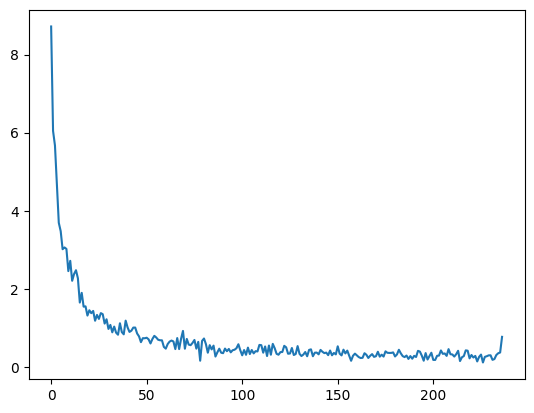

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.title("Loss by Epoch")
plt.show()

### Modularized Version of Training

In [31]:
from dataclasses import dataclass

@dataclass 
class SimpleMLPTrainingArgs:
    batch_size: int = 64
    epochs:     int = 3
    lr:       float = 1e-3


def train(args: SimpleMLPTrainingArgs) -> tuple[list[float], SimpleMLP]:
    """
    Trains and returns the model, using training parameters from the `args` object. Returns the model, and loss list
    """

    model = SimpleMLP().to(device)

    mnist_train, _ = get_mnist()
    mnist_trainloader = DataLoader(
        mnist_trainset, batch_size=args.batch_size, shuffle=True
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    loss_list = []

    for epoch in range(args.epochs):
        pbar = tqdm(mnist_trainloader)

        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)

            # calculate loss
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # update logs and progress bar
            loss_list.append(loss.item())
            pbar.set_postfix(epoch=f"{epoch + 1}/{args.epochs}", loss=f"{loss:.3f}")

    return loss_list, model


args = SimpleMLPTrainingArgs()
loss_list, model = train(args)

100%|██████████| 157/157 [00:00<00:00, 218.18it/s, epoch=3/3, loss=0.055]


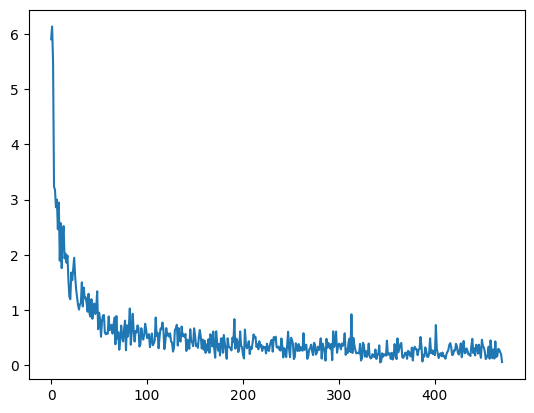

In [32]:
plt.plot(loss_list)
plt.show()